## MODEL EVALUATION

In this tutorial, we will show how to render a model once it is built. First, let's import a pre-built model from the zoo to speed up the process.


In [29]:
from zoo import Gaussian1D


gaussian = Gaussian1D()

print(gaussian)

MODEL NAME: Gaussian1D 
FREE PARAMS: 3
GRID VARIABLES: ['x']
______________________________________________________________________
     NOME            VALORE     FREEZE     BOUNDS              
______________________________________________________________________
0    amp             1.00       0          (-inf, inf)         
1    x0              1.00       0          (-inf, inf)         
2    stddev          1.00       0          (-inf, inf)         



### METHOD 1 - EVALUATION METHOD

The first method presented uses the `evaluate` function associated with each model. This function has as its only mandatory parameter the grid on which the model is defined.

When no other elements are provided to the function, the default values of the parameters associated with the model are used.


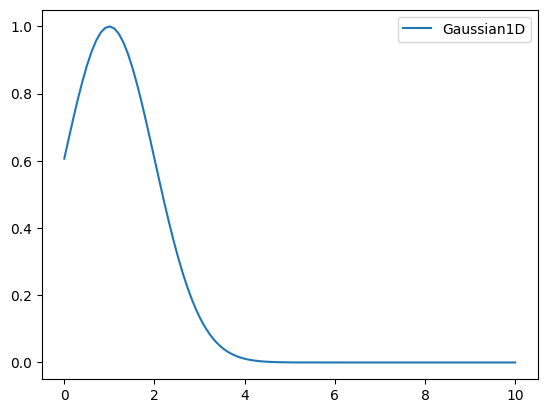

In [30]:
import matplotlib.pyplot as plt
import numpy as np

# define the grid
X = np.linspace(0,10,100)

#evaluate the model over the grid
values = gaussian.evaluate(X)

#plot the results
plt.plot(X, values, label=f'{gaussian.name}')
plt.legend()
plt.show()

Optionally, the remaining values can be specified as __*args__ or __**kwargs__.


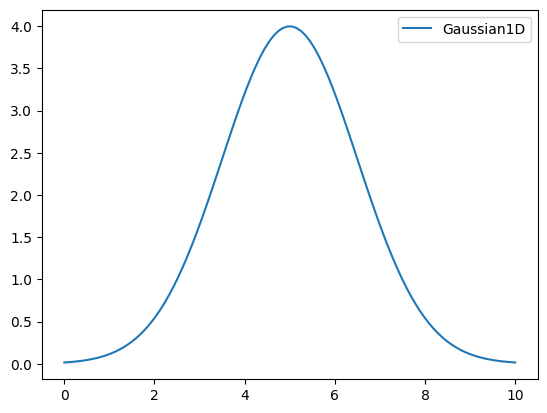

In [31]:
values = gaussian.evaluate(X, 4, 5, 1.5)

#values = gaussian.evaluate(X, amp = 4, x0 = 5, stddev=1.5)

# plot the results
plt.plot(X, values, label=f"{gaussian.name}")
plt.legend()
plt.show()

Although convenient, this method does not impose any restrictions on the values or the number of entries to specify, and it does not distinguish between models with frozen values or not. This is a simple method to evaluate the model at any point in the parameter space but not necessarily the most suitable for optimization purposes.

we can see that this allow for the evaluation of the model also in the case of frozen parameters...

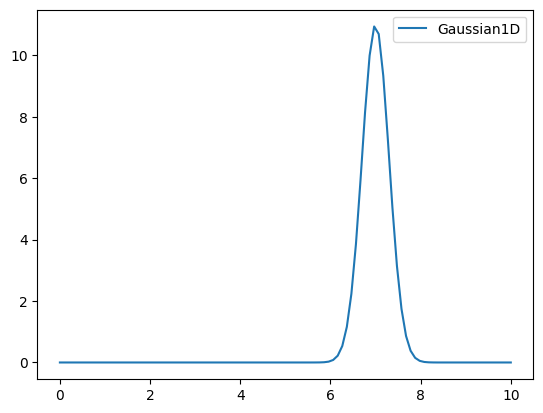

In [32]:
# we freeze the model
gaussian.freeze_parameters()

values = gaussian.evaluate(X, amp=11, x0=7, stddev=0.3)

plt.plot(X, values, label=f"{gaussian.name}")
plt.legend()
plt.show()

### METHOD 2 - __CALL__ METHOD

For this reason, the `__call__` method associated with the models takes into account the distinction between the grid and parameters. Additionally, frozen parameters are not required as input (providing them would result in an error).

To render a model considering frozen parameters and the grid, simply use it as a function. This method imposes very strict restrictions, and ignoring them will trigger fatal errors. However, it is the best method to handle the separate presence of the grid and frozen parameters.


Through the `__call__` method, frozen parameters are not required in the function call, effectively reducing the dimensionality of the parameter space. The syntax is also slightly different, requiring two lists as input: one for the grid and one for the parameters. The parameter list must have the dimensions of the number of free parameters and can optionally be replaced by a dictionary containing the parameter names.

Even in this case, the grid is the only mandatory key. If it is not provided, the default parameters will be used.


MODEL NAME: Gaussian1D 
FREE PARAMS: 2
GRID VARIABLES: ['x']
______________________________________________________________________
     NOME            VALORE     FREEZE     BOUNDS              
______________________________________________________________________
0    amp             1.00       0          (-inf, inf)         
1    x0              1.00       1          (-inf, inf)         
2    stddev          1.00       0          (-inf, inf)         



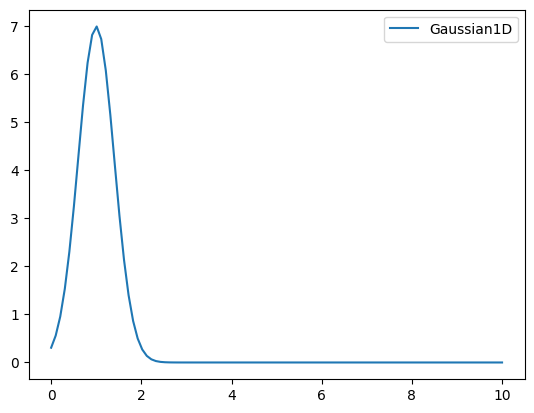

In [33]:
# we unfreeze the amplitude and stddev
gaussian.unfreeze_parameters(0, 2)

print(gaussian)

values = gaussian([X], [7, 0.4])  # amp = 7, x0=freeze, stddev = 0.4

# or equivlent to
values = gaussian(grid=[X], params={"amp": 7, "stddev": 0.4})

plt.plot(X, values, label=f"{gaussian.name}")
plt.legend()
plt.show()

63.948090535403836
(1, 100)
[63.948090535403836, 63.83586670653079, 63.48805077486964, 63.29473302417728]


 46%|████▌     | 410/900 [00:00<00:00, 9646.24it/s]

Treshold raggiunta
[10.58874681  6.53281964  1.49992556]
Parametri ottimizzati (mu, sigma, A): [10.58874681  6.53281964  1.49992556]


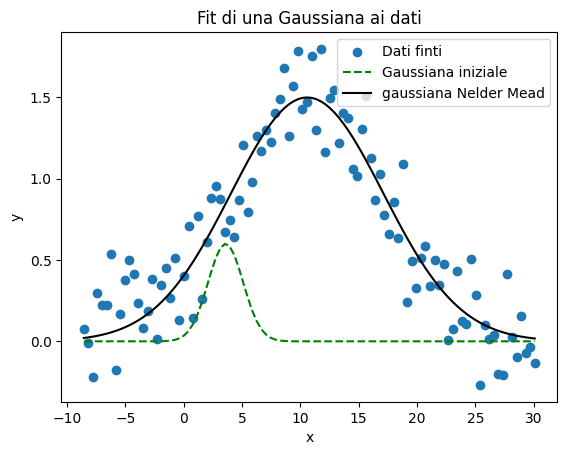

In [1]:
from zoo import Fittable1D
from optimizers import NelderMead
import numpy as np
import matplotlib.pyplot as plt


class Gaussian1D(Fittable1D):
    @staticmethod
    def evaluate(x, mu, sigma, A):
        return A * np.exp(-((x - mu) ** 2) / (2 * sigma**2))


gaus = Gaussian1D()


# Generazione di dati finti
def generate_fake_data(mu, sigma, A, num_points=100, noise_level=0.2):
    x = np.linspace(mu - 3 * sigma, mu + 3 * sigma, num_points)
    y_true = Gaussian1D.evaluate(x, mu, sigma, A)
    noise = noise_level * np.random.randn(num_points)
    y_noisy = y_true + noise
    return x, y_noisy


# Parametri veri per la generazione dei dati finti
true_mu = 10.77
true_sigma = 6.44
true_A = 1.5

# Genera dati finti
x_data, y_data = generate_fake_data(true_mu, true_sigma, true_A)

# Punto iniziale per l'algoritmo di Nelder-Mead
initial_guess = [3.6, 1.5, 0.6]  # [mu, sigma, A]

optimizer = NelderMead(model=gaus, treshold=1e-6, delta=0.1)

print(optimizer.loss([x_data], initial_guess, y_data))
print((np.shape([x_data])))
results = optimizer.minimize(
    x0=initial_guess, grid=[x_data], data=[y_data], progress=True
)
print(results)


print("Parametri ottimizzati (mu, sigma, A):", results)


# Grafico dei dati originali e della curva ottimizzata
plt.scatter(x_data, y_data, label="Dati finti")

plt.plot(
    x_data,
    gaus([x_data], initial_guess),
    color="green",
    linestyle="--",
    label="Gaussiana iniziale",
)

plt.plot(x_data, gaus([x_data], results), c="black", label="gaussiana Nelder Mead")

plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.title("Fit di una Gaussiana ai dati")
plt.show()